In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import os
import csv

In [4]:
def load_data(dataset_root='../FORTH_TRACE_DATASET', save_path='all_data.npy'):
    # Se o arquivo já existe, lê direto
    if os.path.exists(save_path):
        print("A carregar os dados do arquivo salvo...")
        return np.load(save_path)
    
    print("A ler os dados do CSV...")
    data_rows = []
    for part_id in range(15):
        dataset_path = f"{dataset_root}/part{part_id}"
        participant_id = part_id
        for dev_id in range(1, 6):
            csv_file = f"{dataset_path}/part{part_id}dev{dev_id}.csv"
            with open(csv_file, 'r', newline='') as f:
                reader = csv.reader(f, delimiter=',')
                for row in reader:
                    arr = np.array(row, dtype=float)
                    new_row = np.hstack((np.array([participant_id], dtype=float), arr))
                    data_rows.append(new_row)

    data = np.vstack(data_rows)
    
    # Salva em .npy para carregar rápido na próxima vez
    np.save(save_path, data)
    print(f"Dados salvos em {save_path}")
    
    return data

# Usar a função
data = load_data()
print(data[:5])
# Carregar dados
data = np.load('all_data.npy')
print(data.shape)  # ver dimensão (linhas, colunas)
print(data[:5])    # mostrar as primeiras 5 linhas

A ler os dados do CSV...
Dados salvos em all_data.npy
[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.0134e+00  5.0589e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7963e+00  9.3742e+00  2.4460e+00 -1.5618e+00
  -6.6165e-01  5.9730e-01 -3.4274e-01  5.7631e-01  1.0000e+00  5.2542e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.8696e+00  9.3000e+00  2.3514e+00 -1.1877e+00
  -1.2841e+00  1.4212e-01 -3.4476e-01  5.9639e-01  1.0156e+00  5.4495e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7961e+00  9.3624e+00  2.4584e+00 -5.8399e-01
  -2.0334e+00  4.2912e-01 -3.2863e-01  6.2249e-01  1.0156e+00  5.6448e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.6768e+00  9.3506e+00  2.4685e+00 -3.7050e-01
  -1.3647e+00  3.7194e-01 -3.3669e-01  6.2048e-01  1.0245e+00  5.8401e+02
   1.0000e+00]]
(3930873, 13)
[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9

## 1.1

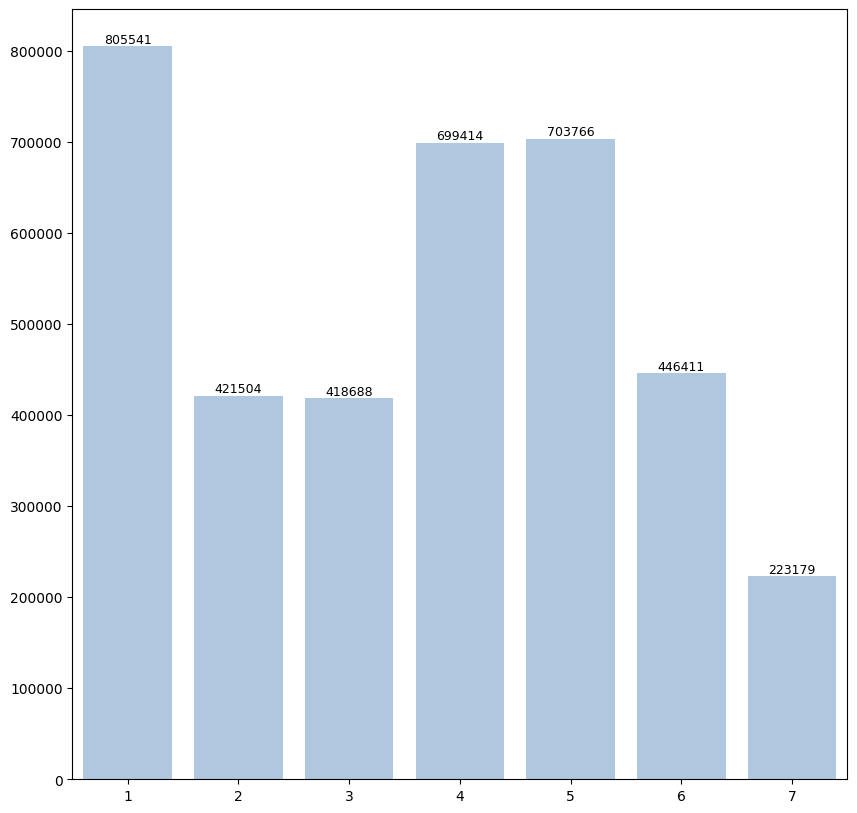

In [5]:
activity_labels = data[:, 12].astype(int)

# Filtrar apenas atividades 1 a 7
mask = (activity_labels >= 1) & (activity_labels <= 7)
data_filtered = data[mask]
filtered_labels = activity_labels[mask]

# Contar exemplos por atividade
atividades, contagens = np.unique(filtered_labels, return_counts=True)

# Plot com seaborn
plt.figure(figsize=(10,10))
grafico = sns.barplot(x=atividades, y=contagens, color='#A7C7E7')
grafico.bar_label(grafico.containers[0], fontsize=9)
plt.show()


## 1.2

In [6]:

def generate_smote_samples(dataset, activity_label, K, k_neighbors=5):
    X = dataset[:, :-1]
    y = dataset[:, -1].astype(int)
    
    current_count = np.sum(y == activity_label)
    
    target_count = current_count + K
    sampling_strategy = {activity_label: target_count}
    
    smote = SMOTE(sampling_strategy=sampling_strategy, k_neighbors=k_neighbors)
    X_res, y_res = smote.fit_resample(X, y)
    
    dataset_augmented = np.hstack((X_res, y_res.reshape(-1,1)))
    return dataset_augmented

## 1.3

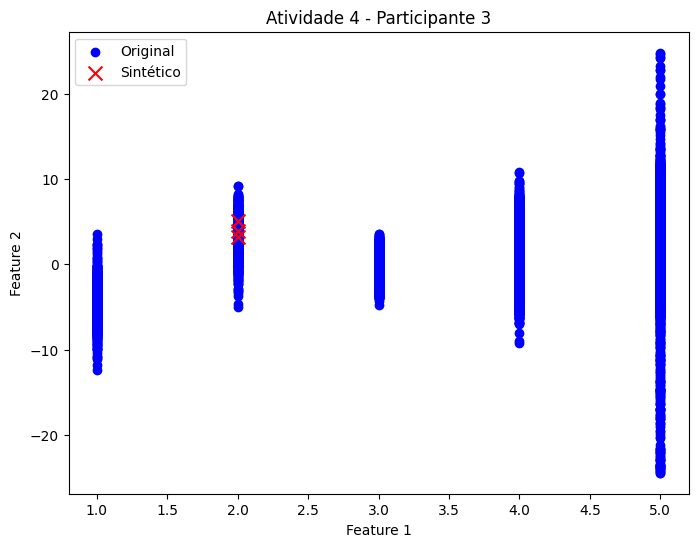

In [7]:
# Filtrar apenas participante 3
participant_id = 3
mask_participant = data[:, 0] == participant_id
data_participant = data[mask_participant]

# Gerar 3 novas amostras para atividade 4
activity_label = 4
data_augmented = generate_smote_samples(data_participant, activity_label=activity_label, K=3)

# Separar exemplos 
data_activity_original = data_participant[data_participant[:, 12] == activity_label]
num_original = data_activity_original.shape[0]

# Filtrar apenas atividade 4
data_activity_augmented = data_augmented[data_augmented[:, 12] == activity_label]
synthetic_samples = data_activity_augmented[num_original:]  # últimos k
original_samples = data_activity_augmented[:num_original]

# Plotar o pedido
plt.figure(figsize=(8,6))
plt.scatter(original_samples[:, 1], original_samples[:, 2], color='blue', label='Original')
plt.scatter(synthetic_samples[:, 1], synthetic_samples[:, 2], color='red', label='Sintético', marker='x', s=100)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Atividade {activity_label} - Participante {participant_id}')
plt.legend()
plt.show()


-------------------------------------------------------------------------------

# Exercício 2 - Embedding Features

In [ ]:
#codigo do stor do embedding 
import torch
import numpy as np


def load_model():
  ''' Loads the model from the github repo and obtains just the feature encoder. '''

  repo = 'OxWearables/ssl-wearables'
  # class_num não interessa para extrair features; mas o hub pede este arg
  model = torch.hub.load(repo, 'harnet5', class_num=5, pretrained=True)
  model.eval()

  # Passo crucial: ficar só com a parte auto-supervisionada
  # O README diz que há um 'feature_extractor' (pré-treinado) e um 'classifier' (não treinado). :contentReference[oaicite:14]{index=14}
  feature_encoder = model.feature_extractor
  feature_encoder.to("cpu")
  feature_encoder.eval()

  return feature_encoder


def resample_to_30hz_5s(acc_xyz, fs_in_hz):
    """
    acc_xyz: np.ndarray shape (N, 3) em m/s^2 (ou g), amostrado a fs_in_hz (float)
    devolve:
      acc_resampled: np.ndarray shape (M, 3) já a 30 Hz
      fs_target: 30.0
    """
    fs_target = 30.0
    win_size = 5 # in seconds
    t_in = np.arange(acc_xyz.shape[0]) / fs_in_hz
    t_out = np.arange(0, win_size, 1.0/fs_target)

    acc_resampled = np.zeros((len(t_out), 3), dtype=np.float32)
    for axis in range(3):
        acc_resampled[:, axis] = np.interp(t_out, t_in, acc_xyz[:, axis])

    return acc_resampled, fs_target


def acc_segmentation(data):
  ''' Estract ACC segments and their activities '''

  TIMESTAMP_COL = 10
  MIN_SEGMENT_SIZE = 20
  fs_in_hz = 51.5
  win_size = 5000
  start_time = data[0,TIMESTAMP_COL]
  end_time = start_time + win_size

  activities = []
  segments = []

  while end_time < data[-1,TIMESTAMP_COL]:
    mask = (data[:,TIMESTAMP_COL] >= start_time) & (data[:,TIMESTAMP_COL] < end_time)

    if np.sum(mask) > MIN_SEGMENT_SIZE and np.all(data[mask, -1] == data[mask, -1][0]):

      acc_xyz = data[mask,1:4]
      activity = data[mask, -1][0]
      
      activities.append(activity)
      segments.append( acc_xyz )
      

    start_time = end_time - win_size/2
    end_time = start_time + win_size
  
  
  return segments, activities



# load example file to test embedding
csv_file_path = '../FORTH_TRACE_DATASET/part13/part13dev1.csv'
 
csv_data = np.loadtxt(csv_file_path, delimiter=',')

original_segments, activities = acc_segmentation(csv_data)

resampled_segments = [resample_to_30hz_5s(segment, 51.5)[0] for segment in original_segments]

feature_encoder = load_model()


embeddings_list = []

# reshape segments to [n_segments, dimensions(xyz), time]
x_all = np.transpose( np.array(resampled_segments), (0, 2, 1) )
print(x_all.shape)

# iterate over the resampled segments and pass them 
#    through the model in batches to get the embeddings
batch_size = 5
with torch.no_grad():
    for i in range(0, x_all.shape[0], batch_size):
        xb = torch.from_numpy(x_all[i:i+batch_size]).float().to("cpu")
        eb = feature_encoder(xb)  # (B, D_embed)
        embeddings_list.append(eb.cpu().numpy())

embeddings = np.concatenate(embeddings_list, axis=0)
print(embeddings.shape)

Using cache found in C:\Users\HP/.cache\torch\hub\OxWearables_ssl-wearables_main


131 Weights loaded
(369, 3, 150)
(369, 512, 1)


In [ ]:
# atividade 1-7
mask = (activity_labels >= 1) & (activity_labels <= 7)
data_filtered = data[mask]
filtered_labels = activity_labels[mask]

# acelerometro
accel_data = data_filtered[:, 1:4]

# 5 segundos
segments, activities = acc_segmentation(data_filtered)

# resample cada segmento para 30Hz
resampled_segments = [resample_to_30hz_5s(seg, 51.5)[0] for seg in segments]


feature_encoder = load_model()


x_all = np.array([seg.T for seg in resampled_segments], dtype=np.float32)  
print(x_all.shape)


# Gerar embeddings
embeddings_list = []
batch_size = 5
with torch.no_grad():
    for i in range(0, x_all.shape[0], batch_size):
        xb = torch.from_numpy(x_all[i:i+batch_size]).float().to("cpu")
        eb = feature_encoder(xb)  # (B, D_embed)
        embeddings_list.append(eb.cpu().numpy())


embeddings_dataset = np.concatenate(embeddings_list, axis=0)
print(f"Embeddings dataset shape: {embeddings_dataset.shape}")  




131 Weights loaded
(0,)


Using cache found in C:\Users\HP/.cache\torch\hub\OxWearables_ssl-wearables_main


ValueError: need at least one array to concatenate